# Aprendizaje Estadístico y Data Mining

## Práctica 1: Consumo de Cerveza

### **Objetivo**
Una tienda online de venta de cerveza quiere hacer un estudio de mercado. En el país donde opera hay
problemas con los envíos debido a su extensión, se quiere implementar un sistema que pueda predecir varios
parámetros. Algunos de ellos pueden influir en el consumo y por lo tanto en las ganancias y el stock del
almacén. Para cada uno de lossiguientes casos: calcula y establece que tipo de relación hay entre las variables,
dibuja un diagrama de dispersión con los casos en el que también se incluya el modelo obtenido y por último
haz una predicción con varios datos.

## **Solución**

### Importación de librerías

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

### Carga y preprocesamiento del dataset

Para el preprocesamiento, eliminaremos aquellas filas que no tienen datos (NaN), y comprobaremos que no haya datos duplicados para un mismo instante de tiempo.

Además, alteraremos el dataset para que *Python* detecte decimales intercambiando las *","* por los "*.*" y que no ignore esos datos. Por último, convertiremos la Columna *Data* a tipo Datetime, para poder trabajar con fechas.

In [143]:
#1.1 Cargamos el dataset en un dataframe
df = pd.read_csv('.\\data\\Consumo_cerveza.csv')

#1.2 Reemplazamos las comas por puntos para que python lo interprete como decimales
for col in ['Temperatura Media (C)', 'Temperatura Minima (C)', 'Temperatura Maxima (C)', 'Precipitaciones (mm)']:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

#1.3 Convertimos las fechas de Data a tipo Datetime
df['Data'] = pd.to_datetime(df['Data'])

#2.1 Para el preprocesamiento, primero observamos las características del dataset original
print(f"Número de filas iniciales: {df.shape[0]}")

#2.2 Observamos los valores nulos por columna, para decidir qque hacer con ellas
print("\nValores nulos por columna:")
print(df.isnull().sum())

#2.3 Eliminamos aquellas filas completamente nulas si las hay
df = df.dropna(how='all')

#2.4Observamos y eliminamos la existencia de duplicados si los hay
duplicados = df.duplicated().sum()
print(f"\nbNúmero de filas duplicadas: {duplicados}")

if duplicados > 0:
    df = df.drop_duplicates()
    print("Duplicados eliminados.\n")

#2.5 Número de final tras preprocesar el dataset
print(f"\nNúmero de filas finales: {df.shape[0]}")



Número de filas iniciales: 941

Valores nulos por columna:
Data                           576
Temperatura Media (C)          576
Temperatura Minima (C)         576
Temperatura Maxima (C)         576
Precipitaciones (mm)           576
Fin de Semana                  576
Consumo de cerveza (litros)    576
dtype: int64

bNúmero de filas duplicadas: 0

Número de filas finales: 365


## Caso 1

### Análisis Exploratorio
Mediante un histograma, veremos la distribución de las variables clave para entender un poco mejor los datos del dataset para este primer caso:

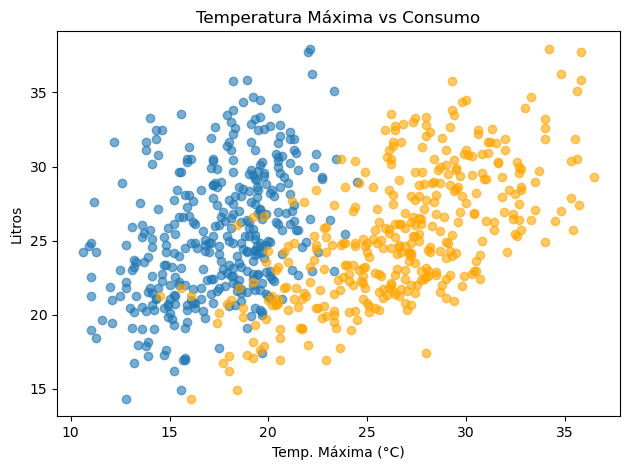

In [144]:
#1.1 Relación entre Temp. Mínima vs Consumo
plt.subplot(1, 1, 1)
plt.scatter(df['Temperatura Minima (C)'], df['Consumo de cerveza (litros)'], alpha=0.6)
plt.title('Temperatura Mínima vs Consumo')
plt.xlabel('Temp. Mínima (°C)')
plt.ylabel('Litros')

#1.2  Relación entre Temp. Máxima vs Consumo
plt.subplot(1, 1, 1)
plt.scatter(df['Temperatura Maxima (C)'], df['Consumo de cerveza (litros)'], alpha=0.6, color='orange')
plt.title('Temperatura Máxima vs Consumo')
plt.xlabel('Temp. Máxima (°C)')

plt.tight_layout()
plt.show()

### Coeficiente de Pearson $r$
Este coeficiente de correlación nos muestra el tipo de correlación lineal que podrían tener las variables que usaremos en este caso. Queremos cuantificar la intensidad de la relación entre dos variables.

Para entender el valor resultante de esa $r$, nos basaremos en lo siguiente:
- $r$ cerca de $1$ → relación **positiva** fuerte.
- $r$ cerca de $-1$ → relación **negativa** fuerte.
- $r$ cerca de $0$ → **no hay relación**.

- Correlación Tmin vs Consumo: Correlación entre Temperatura Minima (C) y Consumo de cerveza (litros)
- Correlación Tmax vs Consumo: Correlación entre Temperatura Máxima (C) y Consumo de cerveza (litros)

In [145]:
#1.1 Calculamos las correlaciones
corr_min = df['Temperatura Minima (C)'].corr(df['Consumo de cerveza (litros)'])
corr_max = df['Temperatura Maxima (C)'].corr(df['Consumo de cerveza (litros)'])

print(f"\nCorrelación de Pearson:\n\t- Tmin vs Consumo: {corr_min:.2f}\n\t- Tmax vs Consumo: {corr_max:.2f}")


Correlación de Pearson:
	- Tmin vs Consumo: 0.39
	- Tmax vs Consumo: 0.64


Por lo tanto, vemos como la Temperatura Mínima influye más bien poco en el consumo de cerveza, al encontrarse relativamente cerca del $r=0$. Sin embargo, sigue siendo una correlación positiva, aunque la calificaríamos como débil o moderada. Por lo tanto, al aumentar la Temperatura Mínima, aumenta ligeramente el Consumo de cerveza.

Por el otro lado, las temperaturas altas influyen de una manera bastante notoria en el consumo de cerveza, al encontrarse más cerca de una $r = 1$ que del $0$. Por lo tanto, si aumenta la Temperatura Máxima, aumenta moderadamente el Consumo de cerveza.

### **Regresión**: Definición y Entrenamiento de los **modelos**

Definiremos dos modelos para visualizar las predicciones que hacen cada uno y comparar que temperatura es la que más afecta (supuestamente) al consumo de cerveza. 

El objetivo radica en obtener estimaciónes razonables de la variable predictora Y para distintos valores dependientes de X a partir de una muestra de valores del dataset.

La definición de las variables nos muestra como nos encontramos ante dos modelos de **regresión lineal simple**, por lo que el modelo adoptará la forma de una **línea** en el espacio **bidimensional**.

El resultado de entrenar estos modelos nos proporcionará la siguiente información: 
- Si ambas variables están relacionadas o si son independientes.
- Conocer el grado y tipo de relación entre ambas variables.
- Predecir la variable dependiente a partir de los valores de la independiente, y ver su precisión.

In [146]:
#1.1 Función de entrenamiento para un modelo de regresión lineal simple.
def entrenar_modelo(X, y, nombre):
    model = LinearRegression()
    model.fit(X, y)
    
    #1.2 Obtenemos la información resultante de entrenar el modelo con esas variables.
    r2 = r2_score(y, model.predict(X))
    print(f"\nModelo {nombre}:")
    print(f" - Intercepto (β0): {model.intercept_:.2f}")
    print(f" - Pendiente (β1): {model.coef_[0]:.2f}")
    print(f" - R²: {r2:.2f}")
    
    return model

In [147]:
#1.1 Modelo para Temperatura Mínima vs Consumo 
# 1.1.1 La temperatura mínima es la variable independiente y predictora
X_min = df[['Temperatura Minima (C)']]
# 1.1.2 El consumo de cerveza es la variable dependiente y objetivo, la que nos interesa predecir.
model_min = entrenar_modelo(X_min, df['Consumo de cerveza (litros)'], 'Temp. Mínima')

# Modelo para Temperatura Máxima vs Consumo
X_max = df[['Temperatura Maxima (C)']]
model_max = entrenar_modelo(X_max, df['Consumo de cerveza (litros)'], 'Temp. Máxima')


Modelo Temp. Mínima:
 - Intercepto (β0): 14.73
 - Pendiente (β1): 0.61
 - R²: 0.15

Modelo Temp. Máxima:
 - Intercepto (β0): 7.97
 - Pendiente (β1): 0.65
 - R²: 0.41


### **Visualización** de los modelos
Graficaremos ahora los resultados, mostrando una **línea de regresión** que se superpone en los diagramas de dispersión antes mostrados.


In [148]:
def plot_modelo(X, y, model, title, color):
    plt.scatter(X, y, alpha=0.5, label='Datos reales')
    plt.plot(X, model.predict(X), color=color, linewidth=2, 
             label=f'y = {model.intercept_:.1f} + {model.coef_[0]:.1f}x')
    plt.title(title)
    plt.xlabel('Temperatura (°C)')
    plt.ylabel('Consumo (litros)')
    plt.legend()


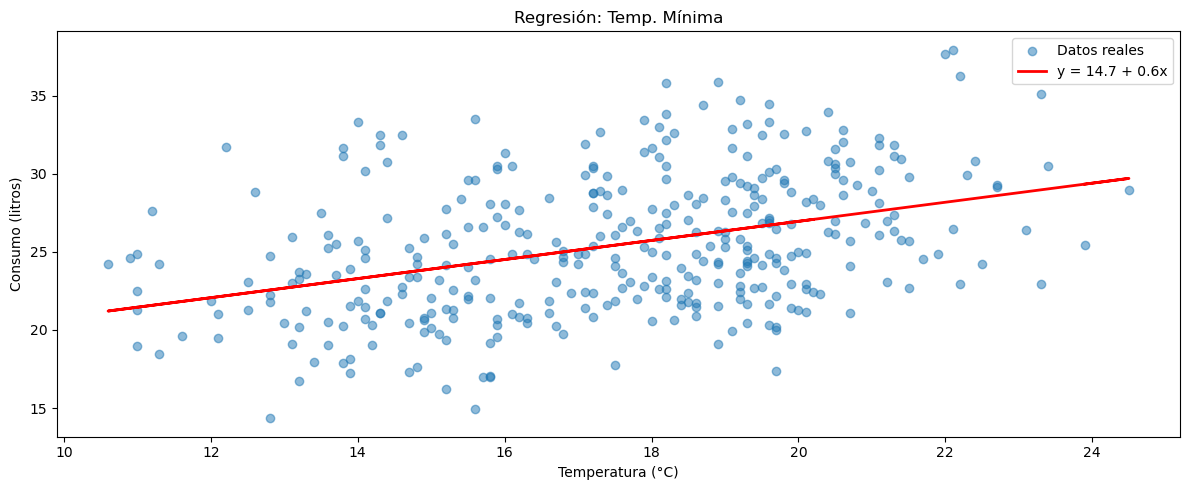

In [149]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)
plot_modelo(X_min, df['Consumo de cerveza (litros)'], model_min, 
           'Regresión: Temp. Mínima', 'red')

plt.tight_layout()
plt.show()

Tmin vs Consumo: De esta gráfica de regresión podemos intuir que se da una cohesión entre dos tipos de regresión:
- Lineal Positiva: La función 0.6x es lineal y 0.6 es mayor que 0. Tiene "cierto" aspecto de recta y la variable Y aumenta según aumenta X en algunos casos, pero muy lentamente.
- No correlados: Sin embargo, la distribución de los pares parece demasiado dispersa para ser considderada una regresión totalmente lineal y positiva. 
  
Concluimos que se da una sinergia entre estos dos tipos, lo que sugiere que la Temperatura mínima no es una buena variable predictora y no esta tan correlada como se querría

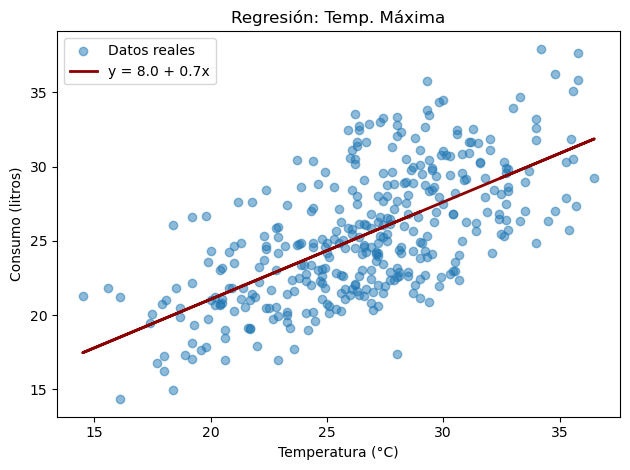

In [150]:
plt.subplot(1, 1, 1)
plot_modelo(X_max, df['Consumo de cerveza (litros)'], model_max, 
           'Regresión: Temp. Máxima', 'darkred')

plt.tight_layout()
plt.show()

Tmx vs Consumo: Esta gráfica es claramente representativa de una regresión Lineal Positiva, ya que se dan todos las condiciones:
- Forma de recta
- $B1 > 0$ = $0.7 > 0$
- Y aumenta si X aumenta en la mayoría de los casos

### Análisis Comparativo
Veamos la comparación de los resultados obtenidos en una tabla comparativa:

In [151]:
comparacion = pd.DataFrame({
    'Variable': ['Temp. min', 'Temp. max'],
    'R²': [model_min.score(X_min, df['Consumo de cerveza (litros)']), 
           model_max.score(X_max, df['Consumo de cerveza (litros)'])],
    'Pendiente (°C/litro)': [model_min.coef_[0], model_max.coef_[0]],
    'Correlación': [corr_min, corr_max]
})
print("\nTabla Comparativa:")
print(comparacion)


Tabla Comparativa:
    Variable        R²  Pendiente (°C/litro)  Correlación
0  Temp. min  0.154063              0.610966     0.392509
1  Temp. max  0.413028              0.654846     0.642672


### Predicciones

Una vez hemos calculado todo lo anterior, pasamos a la fase de evaluación, en la que probaremos los modelos y compararemos los resultados obtenidos.

#### Modelo Tmin vs Consumo
En primer lugar, generamos un *dataset de prueba* relativamente pequeño que se compone únicamente de la variable X, la predictora en el modelo que trabaja con Temperaturas Mínimas

In [152]:
#1.0 Necesitamos conocer con que datos se ha entrenado la red, 
# ya que si por ejemplo introducimos una Tmin de -4ºC, y el mínimo registrado en el dataset 
# es de 10ºC, estamos expuestos a errores.
print("Rango de Temperatura Mínima en datos originales:")
print(f"Mínimo: {df['Temperatura Minima (C)'].min()}°C")
print(f"Máximo: {df['Temperatura Minima (C)'].max()}°C")

#1.1 Queremos saber cuantos Litros de Cerveza se consumirán si hacen 10. 15 y 24ºCºC, sabiendo que el mínimo registrado es 10 grados.
temps_prueba_min = pd.DataFrame({'Temperatura Minima (C)': [10, 15, 24]}) 


Rango de Temperatura Mínima en datos originales:
Mínimo: 10.6°C
Máximo: 24.5°C


In [153]:
#1.2 Cargamos en el predictor el dataset de prueba
pred_min = model_min.predict(temps_prueba_min)

#1.3 Observamos las predicciones
print("\nPredicciones de Consumo:")
for temp, p_min in zip(temps_prueba_min['Temperatura Minima (C)'], pred_min):
    print(f" {temp}°C | Min: {p_min:.1f}L")


Predicciones de Consumo:
 10°C | Min: 20.8L
 15°C | Min: 23.9L
 24°C | Min: 29.4L


#### Modelo Tmax vs Consumo
Ahora ejecutaremos el mismo proceso, pero con X siendo la Temperatura Máxima.

Apreciamos que a medida que aumenta la Tmin, aumenta también el Consumo de Cerveza de manera moderada o débil.

In [154]:
#1.0 Necesitamos conocer con que datos se ha entrenado la red, 
# ya que si por ejemplo introducimos una Tmax de 39ºC, y el maximo registrado en el dataset 
# es de 36ºC, estamos expuestos a errores.
print("Rango de Temperatura Mínima en datos originales:")
print(f"Mínimo: {df['Temperatura Maxima (C)'].min()}°C")
print(f"Máximo: {df['Temperatura Maxima (C)'].max()}°C")

#1.1 Queremos saber cuantos Litros de Cerveza se consumirán si hacen 14, 28 y 36ºC, sabiendo que el mínimo registrado es 10 grados.
temps_prueba_max = pd.DataFrame({'Temperatura Maxima (C)': [14, 28, 36]}) 

Rango de Temperatura Mínima en datos originales:
Mínimo: 14.5°C
Máximo: 36.5°C


In [155]:
#1.2 Cargamos en el predictor el dataset de prueba
pred_max = model_max.predict(temps_prueba_max)

#1.3 Observamos las predicciones
print("\nPredicciones de Consumo:")
for temp, p_max in zip(temps_prueba_max['Temperatura Maxima (C)'], pred_max):
    print(f" {temp}°C | Min: {p_max:.1f}L")


Predicciones de Consumo:
 14°C | Min: 17.1L
 28°C | Min: 26.3L
 36°C | Min: 31.5L


Vemos, de nuevo, un crecimiento lineal positivo en las predicciones.

## Caso 2

Este segundo caso habla de añadir también como variable predictora las Precipitaciones, lo que sugiere escalar nuestro modelo de regresi´´on lineal simple a un modelo de **regresión múltiple**

### Análisis Exploratorio de **Relaciones** entre Variables
En primer lugar, analizaremos las relaciones existentes entre las variables, para entender el contexto y la intensidad de estas, y así intuir algunas pistas sobre como será nuestro modelo.


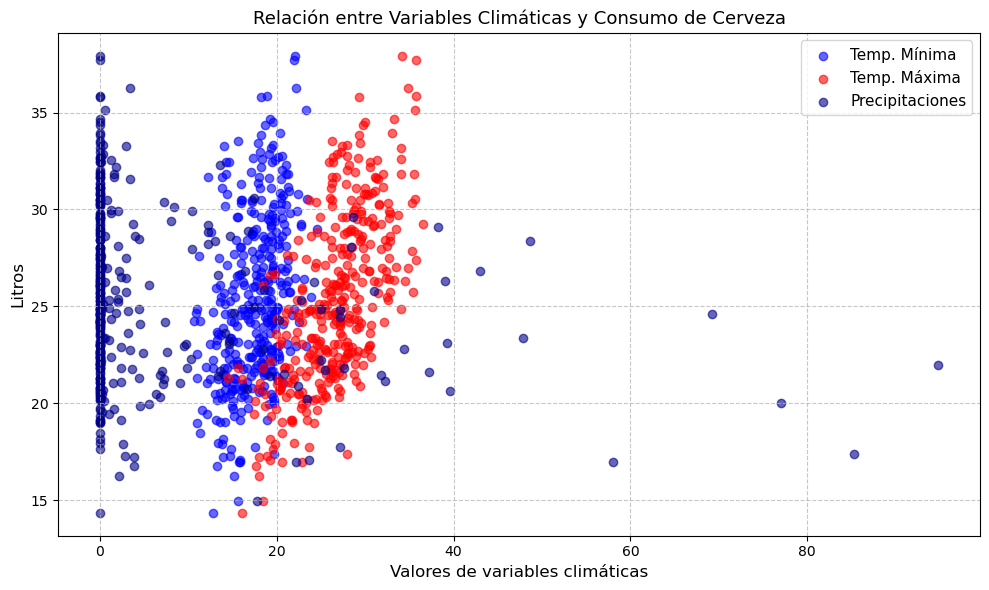

In [156]:
# Creamos un único gráfico con los tres scatter plots
plt.figure(figsize=(10, 6))

# 1.1 Relación entre Temp. Mínima vs Consumo en Azul
scatter_tmin = plt.scatter(df['Temperatura Minima (C)'], df['Consumo de cerveza (litros)'], 
                          alpha=0.6, color='blue')

# 1.2 Relación entre Temp. Máxima vs Consumo en Rojo
scatter_tmax = plt.scatter(df['Temperatura Maxima (C)'], df['Consumo de cerveza (litros)'], 
                          alpha=0.6, color='red')

# 1.3 Relación entre Precipitaciones vs Consumo en Azul Oscuro
scatter_precip = plt.scatter(df['Precipitaciones (mm)'], df['Consumo de cerveza (litros)'], 
                            alpha=0.6, color='darkblue')

#1.4 Añadimos título y etiquetas
plt.title('Relación entre Variables Climáticas y Consumo de Cerveza', fontsize=13)
plt.xlabel('Valores de variables climáticas', fontsize=12)
plt.ylabel('Litros', fontsize=12)

#1.5 Añadimos la leyenda con los objetos scatter
plt.legend(handles=[scatter_tmin, scatter_tmax, scatter_precip], 
          labels=['Temp. Mínima', 'Temp. Máxima', 'Precipitaciones'], 
          fontsize=11, loc='upper right')

#1.6 Añadimos cuadrícula
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Coeficiente de Pearson $r$
Antes de entrar en materia, recordemos y apliquemos de nuevo el Coeficiente de Pearson:

Para entender el valor resultante de esa $r$, nos basaremos en lo siguiente:
- $r$ cerca de $1$ → relación **positiva** fuerte.
- $r$ cerca de $-1$ → relación **negativa** fuerte.
- $r$ cerca de $0$ → **no hay relación**.

In [157]:
#1.1 Calculamos las correlaciones
corr_min = df['Temperatura Minima (C)'].corr(df['Consumo de cerveza (litros)'])
corr_max = df['Temperatura Maxima (C)'].corr(df['Consumo de cerveza (litros)'])
corr_precip = df['Precipitaciones (mm)'].corr(df['Consumo de cerveza (litros)'])

print(f"\nCorrelación de Pearson:\n\t- Tmin vs Consumo: {corr_min:.2f}\n\t- Tmax vs Consumo: {corr_max:.2f}\n\t- Precip vs Consumo: {corr_precip:.2f}")


Correlación de Pearson:
	- Tmin vs Consumo: 0.39
	- Tmax vs Consumo: 0.64
	- Precip vs Consumo: -0.19


De las Temperaturas no hablaremos, pero de la relación entre **Precipitaciones** y **Consumo** vemos un $-0.19$ que nos indica que estas variables no tienen casi ninguna relación entre sí. Ese valor, cercano al $0$, nos indica que existe una relación lineal negativa muy leve, que indica que a medida que se decrementa los valores de Precipitación, también disminuyen los valores del Consumo. Sin embargo, es demasiado leve como para tenerla en cuenta.

### **Regresión Lineal Múltiple**

En este caaso, nos encontramos con $2$ ($k+1$) variables cuantitativas, que corresponden a la X, y una variable de respuesta Y. El proceso es muy similar, consistiendo en extender a las 3 variables cuantitativas las técincas que se usaron en la RL Simple de una sola variable.

Esta es la ecuación tipo de la RLM:

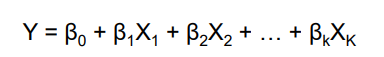

En este caso, nos están pidiendo una ecuación que tendría esta forma:

$$Consumo(Litros) = f(TMin, TMax, Precipitaciones)$$

O lo que es lo mismo:

$$ Consumo = 𝛽₀ + 𝛽₁Tmin + 𝛽₂TMax + 𝛽₃Precip + u$$

Donde:
- 𝛽₀:Intercepto
- 𝛽₁, 𝛽₂, 𝛽₃: Tmin, Tmax y Precip, que influyen en el Consumo de Cerveza
- $u$: Residuo

En cuanto a los **Coeficientes**, sabemos que el Coeficiente de Determinación es:$$R² = SCE/SCT$$
Siendo:
- $SCT$: Variabilidad total de la variable Y (consumo de cerveza).
- $SCE$: Parte de la variabilidad explicada por el modelo (Tmin, Tmax, Precip)
- $R²$: Mide que porcentaje de la variabilidad total podemos explicar con nuestro modelo:
  - Si $R² = 1$, explicamos el 100% de la varibilidad con nuestro modelo.
  - Si $R² = 0$, explicamos el 0%, es un modelo inútil.


Definimos las variables, el modelo y los coeficientes necesarios para la RLM:

In [158]:
#1.1 Variablea para la RLM
X_multi = df[['Temperatura Minima (C)', 'Temperatura Maxima (C)', 'Precipitaciones (mm)']]
y = df['Consumo de cerveza (litros)']

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

#1.2 Coeficientes
print("\nModelo de Regresión Múltiple:")
print(f" - Intercepto (β0): {model_multi.intercept_:.2f}")
for idx, col in enumerate(X_multi.columns):
    print(f" - Coeficiente para {col}: {model_multi.coef_[idx]:.2f}")

#1.3 R² del modelo
r2_multi = model_multi.score(X_multi, y)

#2.1 Veamos si la R2 se corresponde con su ecuación
y_pred = model_multi.predict(X_multi)

#2.2 SCT: Variabilidad total de Y respecto a su media
SCT = np.sum((y - y.mean())**2)


#2.3 SCE: Variabilidad explicada
SCE = np.sum((y_pred - y.mean())**2)

#2.4 R2 manual
R2_manual = SCE / SCT
print(f"R² manualmente calculado: {R2_manual:.4f}")

# 7. Comprobamos que coincide con el R² del modelo
print(f"R² del modelo: {model_multi.score(X_multi, y):.4f}")


Modelo de Regresión Múltiple:
 - Intercepto (β0): 8.79
 - Coeficiente para Temperatura Minima (C): -0.05
 - Coeficiente para Temperatura Maxima (C): 0.67
 - Coeficiente para Precipitaciones (mm): -0.06
R² manualmente calculado: 0.4400
R² del modelo: 0.4400


- Temperatura Mínima: Tiene un coeficiente de -0.05, es decir, por cada grado que aumenta la temperatura mínima, el consumo disminuye ligeramente en 0.05 litros, manteniendo constantes el resto de variables. Su efecto es muy pequeño y negativo.

- Temperatura Máxima: Tiene un coeficiente de 0.67, indicando que por cada grado que aumenta la temperatura máxima, el consumo aumenta en 0.67 litros, manteniendo constantes las demás variables. Es el factor más influyente en el consumo.

- Precipitaciones: Tienen un coeficiente de -0.06, lo que sugiere que por cada milímetro de aumento en la precipitación, el consumo disminuye ligeramente en 0.06 litros. Sin embargo, su influencia también es bastante reducida.

Respecto a la calidad del modelo, el R² obtenido es 0.44, lo cual indica que el 44% de la variabilidad del consumo de cerveza puede explicarse a partir de las tres variables seleccionadas.

La Temperatura Máxima sigue siendo la variable más determinante para explicar el consumo de cerveza, mientras que las Precipitaciones y la Temperatura Mínima tienen un impacto muy limitado.

Veamos ahora los intervalos de confianza para cada coeficiente $βi$:
$$IC(βi)=[βi ± tα/2×error estandar(βi)]$$

Como las pendientes y el intercepto no son coeficientes exactos, debido a la incertiumbre, calculamos los intervalos de confianza que nos dirán que el valor real del coeficiente estará entre X e Y.

Posteriormente, usaremos un contraste de hipótesis para discernir si un coeficiente nos está aportando algo o no.

Los intervalos de confianza del 95% para cada coeficiente serán calculados automáticamente.
- Si el intervalo no contiene el 0, el coeficiente es estadísticamente significativo.
- Si el intervalo sí contiene el 0, el coeficiente no es significativo.

En cuanto al contraste de hipótesis, vemos lo siguiente:
- Hipótesis nula (H₀): El coeficiente de la variable es igual a cero (la variable no influye en el consumo de cerveza).

- Hipótesis alternativa (H₁): El coeficiente de la variable no es igual a cero (la variable influye en el consumo).

Por lo tanto:
 - Con el intervalo de confianza:

   - Si el cero está dentro del intervalo de confianza, no podemos rechazar H₀ → variable no significativa.

   - Si el cero NO está dentro, rechazamos H₀ → variable significativa.
- Con el p-valor:
  - Si p-valor < 0.05 → rechazamos H₀ → la variable es significativa.
  - Si p-valor > 0.05 → no rechazamos H₀ → la variable no es significativa.

In [159]:
import statsmodels.api as sm

# 1.1 Ajustamos el modelo con statsmodels (más completo para inferencia)
X_multi_sm = sm.add_constant(X_multi)  
modelo_sm = sm.OLS(y, X_multi_sm).fit()

# 1.2 Imprimimos el resumen completo (en inglés)
print(modelo_sm.summary())

                                 OLS Regression Results                                
Dep. Variable:     Consumo de cerveza (litros)   R-squared:                       0.440
Model:                                     OLS   Adj. R-squared:                  0.435
Method:                          Least Squares   F-statistic:                     94.55
Date:                         Mon, 28 Apr 2025   Prob (F-statistic):           3.55e-45
Time:                                 18:51:22   Log-Likelihood:                -952.30
No. Observations:                          365   AIC:                             1913.
Df Residuals:                              361   BIC:                             1928.
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

Observamos que tanto el intercepto $([6.464, 11.115])$, como la Tmax $([0.563, 0.779])$ y la Precip $([-0.084, -0.028])$ no incluyen al 0 en su intervalo de confianza, lo que las convierte en estadísticamente significativas. La Tmin $([-0.220, 0.111])$, sin embargo, no es estadísticamente significativa por incluir el 0 en su intervalo. 

Observamos el $p - valor$:
- Temperatura Mínima: No podemos rechazar H₀. → No influye.
- Temperatura Máxima: Rechazamos H₀. → Sí influye.
- Precipitaciones: Rechazamos H₀. → Sí influyen.

En la siguiente tabla veremos los valores que más nos importan del summary anterior, para entender de donde vienen los resultados y como los hemos interpretado:

In [165]:
tabla_hipotesis = pd.DataFrame({
    'Variable': ['TMin', 'TMax', 'Precip'],
    'IC 95%': ['[-0.220, 0.111]', '[0.563, 0.779]', '[-0.084, -0.028]'],
    'Cero en del IC': ['Sí', 'No', 'No'],
    'p-valor': [0.518, 0.000, 0.000],
    '¿Coef significativo?': ['No', 'Sí', 'Sí']
})

print(tabla_hipotesis)

  Variable            IC 95% Cero en del IC  p-valor ¿Coef significativo?
0     TMin   [-0.220, 0.111]             Sí    0.518                   No
1     TMax    [0.563, 0.779]             No    0.000                   Sí
2   Precip  [-0.084, -0.028]             No    0.000                   Sí


## Caso 3

 Para el caso 3, debemos comprobar que la hipótesis de "se cree que es más fácil predecir el consumo de cerveza los fines de con respecto a la
temperatura máxima" se cumple, observando si en los días entre semana la Tmax influye más o menos que en los fines de semana.

Para ello, transformaremos el dataset para separar por fin de semana o entre semana, observando la columna Fin de Semana. Crearemos los modelos correspondientes, teniendo en cuenta esta separación. 

In [161]:
df_finde = df[df['Fin de Semana'] == 1]
df_entresem = df[df['Fin de Semana'] == 0]

#1.1 Modelo para fines de semana
X_fin = df_finde[['Temperatura Maxima (C)']]
y_fin = df_finde['Consumo de cerveza (litros)']
model_fin = LinearRegression().fit(X_fin, y_fin)
r2_fin = model_fin.score(X_fin, y_fin)

#1.2 Modelo para no fines de semana
X_no_fin = df_entresem[['Temperatura Maxima (C)']]
y_no_fin = df_entresem['Consumo de cerveza (litros)']
model_no_fin = LinearRegression().fit(X_no_fin, y_no_fin)
r2_no_fin = model_no_fin.score(X_no_fin, y_no_fin)

print(f"R² en fines de semana: {r2_fin:.2f}")
print(f"R² en días laborables: {r2_no_fin:.2f}")

R² en fines de semana: 0.56
R² en días laborables: 0.60


Antes de aplicar la transformación para crear un modelo de Regresión Lineal Múltiple, veamos un diagrama de dispersión con ambos modelos simples:

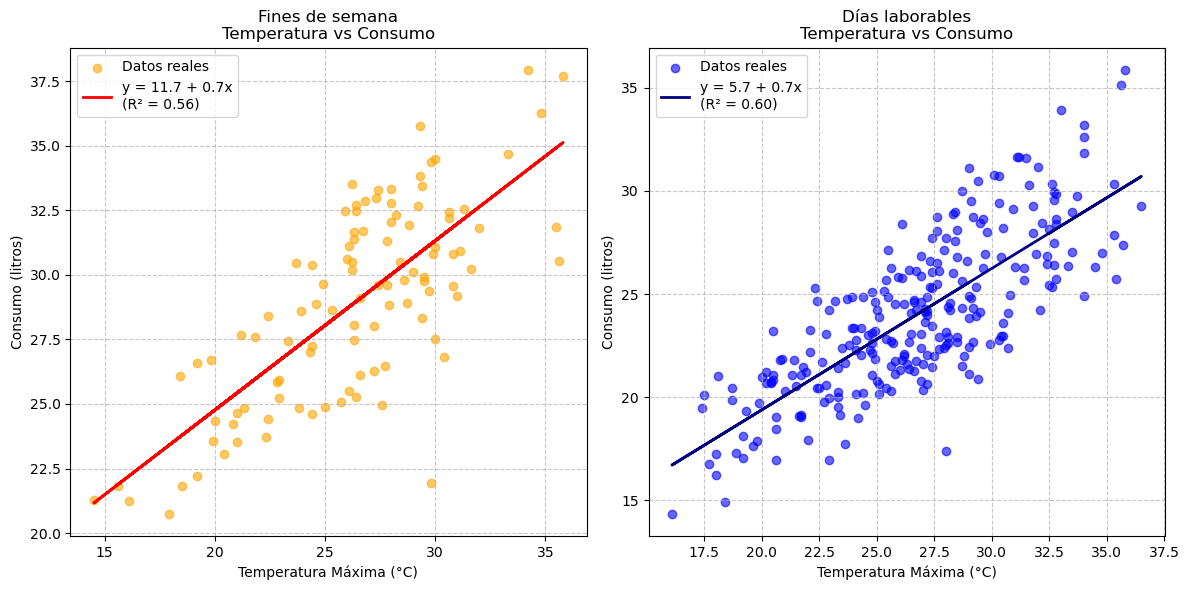

In [162]:
plt.figure(figsize=(12, 6))

# Gráfico para fines de semana
plt.subplot(1, 2, 1)
plt.scatter(df_finde['Temperatura Maxima (C)'], y_fin, alpha=0.6, color='orange', label='Datos reales')
plt.plot(df_finde['Temperatura Maxima (C)'], model_fin.predict(X_fin), 
         color='red', linewidth=2, 
         label=f'y = {model_fin.intercept_:.1f} + {model_fin.coef_[0]:.1f}x\n(R² = {r2_fin:.2f})')
plt.title('Fines de semana\nTemperatura vs Consumo', fontsize=12)
plt.xlabel('Temperatura Máxima (°C)', fontsize=10)
plt.ylabel('Consumo (litros)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico para días laborables
plt.subplot(1, 2, 2)
plt.scatter(df_entresem['Temperatura Maxima (C)'], y_no_fin, alpha=0.6, color='blue', label='Datos reales')
plt.plot(df_entresem['Temperatura Maxima (C)'], model_no_fin.predict(X_no_fin), 
         color='navy', linewidth=2, 
         label=f'y = {model_no_fin.intercept_:.1f} + {model_no_fin.coef_[0]:.1f}x\n(R² = {r2_no_fin:.2f})')
plt.title('Días laborables\nTemperatura vs Consumo', fontsize=12)
plt.xlabel('Temperatura Máxima (°C)', fontsize=10)
plt.ylabel('Consumo (litros)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Contradiciendo nuestra hipótesis, vemos que el $R²$ del modelo de entre semana explica mejor la variabilidad. Además, vemos en el diagrama de dispersión que los puntos se agrupan más entorno a la línea de regresión en el caso de entre semana. Esto sugiere que la variable Tmax es más "influyente" entre semana que en fines de semana.

Sin embargo, ambas están bastante empatadas como para descartar la hipótesis.

Vamos a realizar ahora la transformación que se pide en el enunciado, para llevar a cabo una Regresión Lineal Múltiple. El objetivo es predecir el consumo mensual en función del número de días festivos de ese mes y temperatura máxima promedio.

*Nota: En vez de calcular el número de fines de semana que hay en un mes, hemos decidido calcular el número de días festivos por mes porque aquellos fines de semana que tengan, por ejemplo, el sábado en 31 de enero y el domingo en 1 de febrero, daría un fin de semana de más a cada mes, lo que no tendría sentido.

Calcularemos para cada mes el nº de días festivos (Sabado o Domingo) que tiene, y agruparemos los días en meses con la información promedio (Tmax promedio) de cada mes y el consumo total.

In [163]:
#2.1  Extraemos mes y año
df['Mes'] = df['Data'].dt.to_period('M')

#2.2 Agrupamos por mes y calcular:
# - Número de días festivos
# - Temperatura máxima promedio
# - Consumo total de cerveza
df_mes = df.groupby('Mes').agg(
    num_festivos=('Fin de Semana', 'sum'),
    temp_max_promedio=('Temperatura Maxima (C)', 'mean'),
    consumo_total=('Consumo de cerveza (litros)', 'sum')
).reset_index()
print(df_mes.head())

       Mes  num_festivos  temp_max_promedio  consumo_total
0  2015-01           9.0          31.490323        889.007
1  2015-02           8.0          29.007143        718.848
2  2015-03           9.0          27.248387        776.128
3  2015-04           8.0          25.966667        738.723
4  2015-05          10.0          22.867742        706.750


Una vez tenemos el dataframe transformado, procedemos a entrenar un modelo de Regrersión Lineal Múltiple, en el que las variables X serán:
- Tmax promedio
- Nº de días festivos (Sábado, Domingo)

La Y será: Consumo total de cerveza en ese mes.

In [164]:
#3.1 Definimos las variables
X_mes = df_mes[['num_festivos', 'temp_max_promedio']]
y_mes = df_mes['consumo_total']

#3.2 Entrenamos el modelo y vemos su score
model_mes = LinearRegression().fit(X_mes, y_mes)
r2_mes = model_mes.score(X_mes, y_mes)

#3.3 Predicción ejemplo (9 días festivos, temp. máxima promedio 31°C)
nuevos_datos = pd.DataFrame({
    'num_festivos': [9],
    'temp_max_promedio': [31]
})
pred = model_mes.predict(nuevos_datos)

#3.4 Mostramos resultados
print("Coeficientes:")
print(f" - Por cada día festivo adicional: {model_mes.coef_[0]:.2f} litros")
print(f" - Por cada grado de temperatura máxima: {model_mes.coef_[1]:.2f} litros")
print(f" - Intercepto: {model_mes.intercept_:.2f} litros")

Coeficientes:
 - Por cada día festivo adicional: 23.26 litros
 - Por cada grado de temperatura máxima: 19.14 litros
 - Intercepto: 61.51 litros


## Bibliografía

Regresión Caso 1 - https://www.datacamp.com/es/tutorial/linear-regression-in-python

Tema 6 Data Mining Regresión